# Spotify Audio Intelligence Dashboard

### Exploratory Data Analysis of Spotify Song Features


## Table of Contents

1. Introduction
2. Project Objective
3. Imports
4. Dataset Overview
5. Data Cleaning
6. Exploratory Data Analysis

   * Popularity Distribution
   * Feature Correlation Heatmap
   * Feature Interaction Insights
   * Danceability vs Popularity
   * Energy vs Popularity
   * Acousticness vs Popularity
   * Tempo Distribution
   * Energy vs Loudness
   * Popular vs Non-Popular Tracks
7. Myth Busters
8. Key Takeaways
9. Conclusion

---


---

## Project Objective

The goal of this project is to explore how different Spotify audio features relate to song popularity through exploratory data analysis (EDA).

By examining musical attributes such as **danceability, energy, loudness, acousticness, tempo, and valence**, this analysis aims to identify patterns and relationships that may help explain why certain songs become more popular than others.

The project focuses on the following key objectives:

- Understand the structure and characteristics of the dataset
- Perform data cleaning to ensure reliable analysis
- Explore the distribution of song popularity
- Analyze relationships between different audio features
- Identify correlations and interactions among musical attributes
- Test common assumptions about factors influencing song popularity

Through data visualization and statistical exploration, this project seeks to provide insights into how musical characteristics interact and whether they play a role in determining song popularity.

---

---
## Imports

Before beginning the analysis, the required Python libraries are imported for data manipulation and visualization.

- **NumPy** – numerical operations  
- **Pandas** – data handling and dataset manipulation  
- **Matplotlib** – basic data visualization  
- **Seaborn** – statistical data visualization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")


## Environment Setup

To ensure consistent visualization styling throughout the notebook, a Seaborn theme is applied.

---

---
## Dataset Overview

Before performing exploratory analysis, it is important to understand the basic structure of the dataset. This includes inspecting the dataset's shape, column names, and summary statistics.

By reviewing the dataset structure, we can verify that the relevant features are correctly formatted and suitable for analysis.

In [ ]:
url = "https://drive.google.com/uc?id=1Wr3S8Wfwk8otcuNagSPWRDBFHgR5xdTL"
df = pd.read_csv(url)
df.head()


,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,...,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,track_genre,track_genre_le
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.866025,1.577830,0.186048,1.0,0.132593,0.0,0.0,-1.141849,acoustic,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.866025,1.250904,-0.942392,1.0,-1.658038,0.0,0.0,-1.489701,acoustic,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.507132,-0.057979,1.0,-0.538749,0.0,0.0,-1.528296,acoustic,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.473744,-0.173222,1.0,-1.803951,0.0,0.0,1.987849,acoustic,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500000,1.461916,-0.214050,1.0,-0.528464,0.0,0.0,-0.073343,acoustic,0.0


### Inspecting Dataset Structure

To better understand the dataset, the following checks are performed:

- View the first few rows of the dataset
- Examine the number of rows and columns
- Inspect column data types
- Review summary statistics for numerical features

These steps help ensure that the dataset is clean and ready for analysis.

In [17]:
shape = df.shape
coloumns = df.columns
info = df.info()
describe = df.describe()
print("Shape of the dataset:", shape)
print("Coloumns in the dataset:", coloumns)
print("Information about the dataset:\n", info)
print("Statistical summary of the dataset:\n", describe)

<class 'pandas.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Columns: 159 entries, track_genre_acoustic to track_genre_le
dtypes: float64(158), str(1)
memory usage: 138.3 MB
Shape of the dataset: (113999, 159)
Coloumns in the dataset: Index(['track_genre_acoustic', 'track_genre_afrobeat', 'track_genre_alt-rock',
       'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime',
       'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_blues',
       'track_genre_brazil',
       ...
       'key_cos', 'duration_log', 'duration_log_z',
       'time_signature_class_boolean', 'loudness_yeo', 'is_instrumental',
       'is_dance_hit', 'temp_zscore', 'track_genre', 'track_genre_le'],
      dtype='str', length=159)
Information about the dataset:
 None
Statistical summary of the dataset:
        track_genre_acoustic  track_genre_afrobeat  track_genre_alt-rock  \
count         113999.000000         113999.000000         113999.000000   
mean               0.008772  

**The Dataset Check:**
* **Size:** With over **114,000 tracks**, we have plenty of data to find real trends.
* **The Features:** We have a good mix of technical traits (like tempo and loudness) and artist info.
* **Initial Stats:** Looking at `describe()`, I can already see that popularity varies wildly—most songs are actually quite low on the scale.


#### Observation

The dataset contains a large number of tracks with multiple numerical audio features describing different musical characteristics such as danceability, energy, loudness, acousticness, and tempo.

Most variables appear to be numerical and suitable for statistical analysis and visualization.

#### Analysis

Understanding the dataset structure confirms that the available features can be used to explore relationships between musical attributes and song popularity. With the dataset verified, we can proceed to exploratory data analysis to identify patterns and correlations within the audio features.

---

---
## Data Cleaning

Before beginning the analysis, the dataset is cleaned to ensure reliable results.  
This step involves identifying missing values and removing incomplete or duplicate records that could affect the analysis.

In [97]:
print("Dataset shape before cleaning:", df.shape)
df.dropna(inplace=True)
df = df.drop_duplicates()
print("Dataset shape after cleaning:", df.shape)

Dataset shape before cleaning: (112865, 162)
Dataset shape after cleaning: (112865, 162)



---

---
### Popularity Distribution

Before analyzing relationships between features, it is useful to understand how song popularity values are distributed across the dataset. This visualization shows the spread of popularity scores among all tracks.

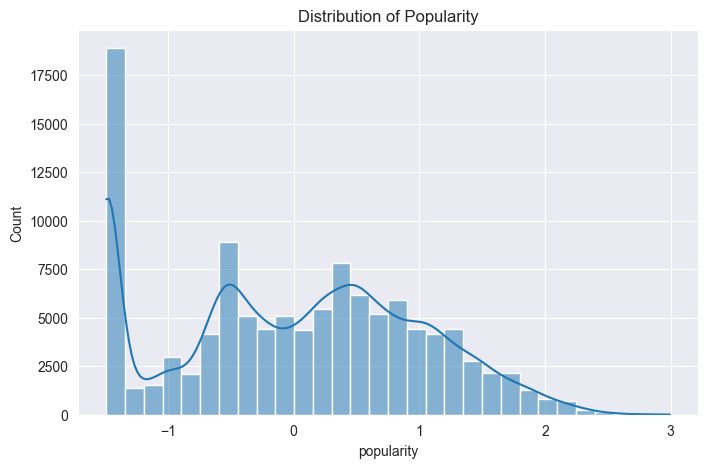

In [88]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'],bins=30,kde=True)
plt.title("Distribution of Popularity")
plt.savefig("../visuals/popularity_distribution.png")
plt.show()

**Observations:**
* **The Massive Spike:** There is a huge peak at the far left (the lowest popularity). 
* **The "Middle Class":** Aside from the spike, most songs follow a standard curve, centered around average popularity.
* **The Rare Hits:** Very few tracks make it to the far right of the graph, showing how rare "Super Hits" actually are.

#### Analysis

This indicates that the majority of tracks achieve moderate listener engagement, while only a smaller portion of songs become highly popular. This pattern is common in entertainment datasets where only a limited number of items achieve widespread success.

---

---
### Feature Correlation Heatmap
A correlation heatmap is used to examine how different audio features relate to one another and to identify patterns of strong positive or negative relationships within the dataset.

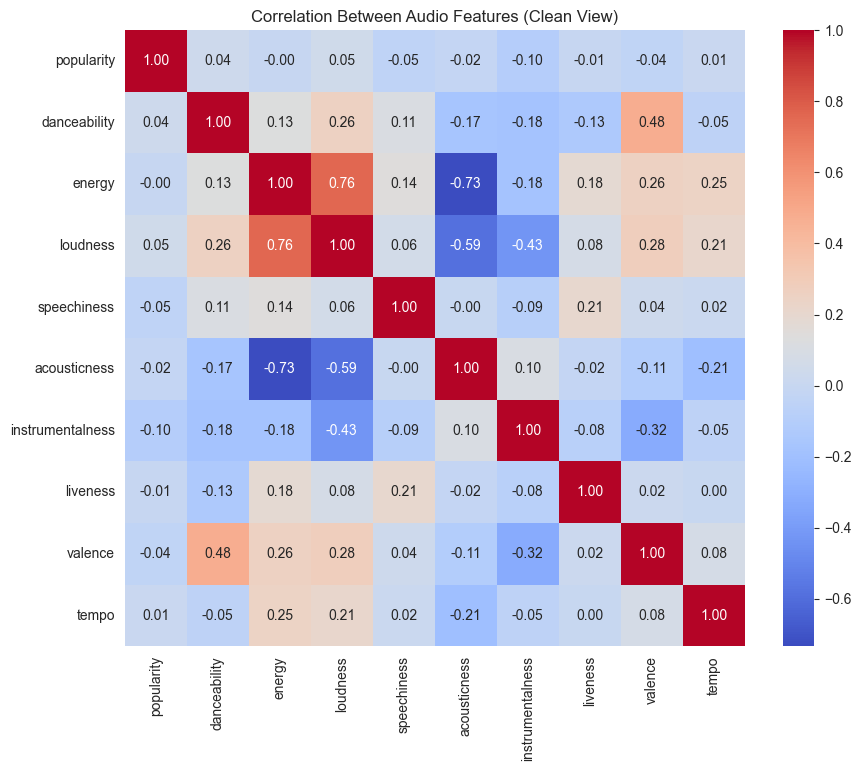

In [89]:
audio_features = ['popularity', 'danceability', 'energy', 'loudness', 
                'speechiness', 'acousticness', 'instrumentalness', 
                'liveness', 'valence', 'tempo']
df_numeric = df[audio_features]
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Between Audio Features (Clean View)")
plt.savefig("../visuals/correlation_heatmap.png")
plt.show()

#### Observation

The correlation heatmap visualizes the relationships between different Spotify audio features. Most features show weak correlations with popularity, indicating that popularity is not strongly associated with any single musical attribute.

However, some strong relationships appear between certain audio features themselves.

#### Analysis

The most notable positive correlation exists between **energy and loudness**, suggesting that energetic songs tend to be produced with higher volume levels. This relationship aligns with typical music production patterns where energetic tracks are designed to sound louder and more intense.

A strong negative correlation is observed between **energy and acousticness**, indicating that songs with higher acoustic characteristics tend to have lower energy levels.

Overall, the heatmap suggests that while some musical features are related to each other, **song popularity does not appear to be strongly determined by any single audio feature in the dataset.**

---

---

## Feature Interaction Insights

The correlation heatmap reveals several meaningful relationships between Spotify audio features.

### Energy and Loudness

Energy and loudness show a strong positive correlation. This indicates that songs with higher energy levels are typically produced with higher volume levels. This relationship reflects common music production practices where energetic tracks are designed to sound louder and more intense.

### Energy and Acousticness

A strong negative relationship is observed between energy and acousticness. Songs with higher acoustic characteristics tend to have lower energy levels, which is expected since acoustic tracks often have softer and more natural sound dynamics.

### Danceability and Valence

Danceability shows a moderate positive relationship with valence. This suggests that songs that are easier to dance to often have a more positive or uplifting musical mood.

### Popularity and Audio Features

Most audio features show very weak correlations with popularity. This indicates that song popularity is not determined by a single musical characteristic but rather by a combination of factors including artist recognition, genre trends, and listener preferences.


These feature interactions provide deeper insight into how musical attributes relate to each other, even when they do not strongly influence popularity directly.

---

---
### Does Danceability Influence Song Popularity?

One common assumption in the music industry is that songs that are easier to dance to tend to perform better with listeners. 

To test this hypothesis, we examine the relationship between **danceability** and **song popularity** using a regression plot.

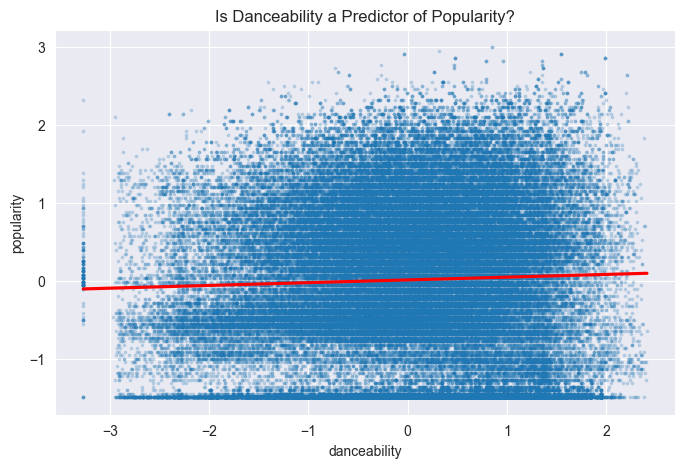

In [91]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='danceability', y='popularity', 
            line_kws={"color": "red"}, 
            scatter_kws={'alpha':0.2, 's':3})
plt.title("Is Danceability a Predictor of Popularity?")
plt.savefig("../visuals/danceability_popularity.png")
plt.show()

#### Observation

The scatter plot shows a wide distribution of popularity values across all levels of danceability. While the regression line shows a slight upward trend, the spread of points is large, indicating that songs with both low and high danceability can achieve similar popularity levels.

#### Analysis

The weak upward trend suggests that danceability may have a mild positive relationship with popularity. However, the relationship is not strong enough to conclude that highly danceable songs consistently achieve higher popularity.

This indicates that while danceability might contribute slightly to a song's success, it is not a dominant factor in determining popularity.

---

---
### Popularity Based on Danceability Quality

To better understand the relationship between danceability and song popularity, the **danceability feature** was categorized into three groups:

- **Poor (Nil)** – very low danceability  
- **Average** – moderate danceability  
- **Excellent (Gud)** – highly danceable songs  

This categorization allows us to compare how popularity varies across different levels of danceability and determine whether more danceable songs tend to achieve higher popularity.

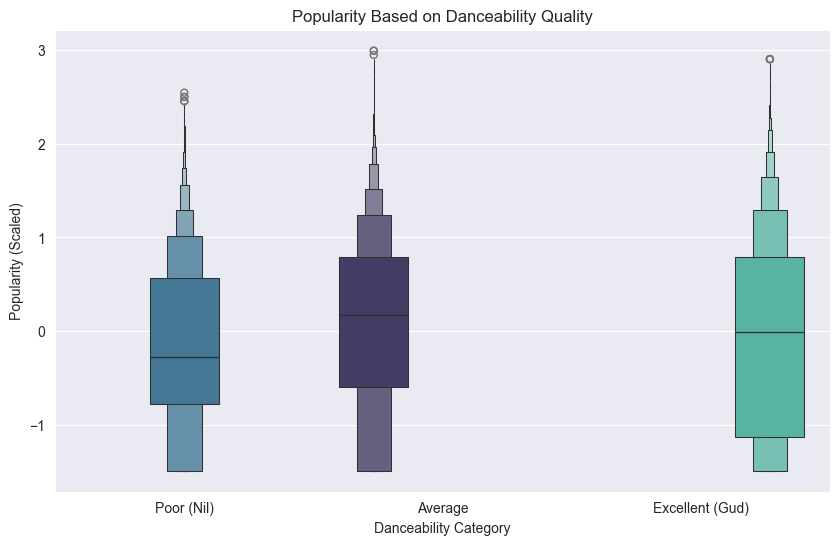

In [96]:
# Categorize danceability into groups
bins = [-np.inf, -1, 1, np.inf]
order = ['Poor (Nil)', 'Average', 'Excellent (Gud)']

df['danceability_category'] = pd.cut(df['danceability'], bins=bins, labels=labels)

# Plot popularity distribution by danceability category
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=df,
    x='danceability_category',
    y='popularity',
    order=order,
    hue='danceability_category',
    palette="mako",
    legend=False
)

plt.title("Popularity Based on Danceability Quality")
plt.xlabel("Danceability Category")
plt.ylabel("Popularity (Scaled)")

plt.savefig("../visuals/danceability_popularity_analysis.png")

plt.show()

#### Observation

The box plot compares the distribution of song popularity across different danceability categories. Songs categorized as **Average** and **Excellent** tend to show slightly higher median popularity values compared to songs in the **Poor** category.

#### Analysis

Although songs with higher danceability appear to have slightly higher popularity on average, the distributions overlap significantly across categories. This suggests that while danceability may contribute to popularity, it is not a dominant factor determining a song’s success.

---

---
### Energy vs Loudness

Energy describes the intensity and activity level of a song, while loudness measures the overall volume of the track.

This analysis explores whether songs with higher energy levels tend to also have higher loudness values.

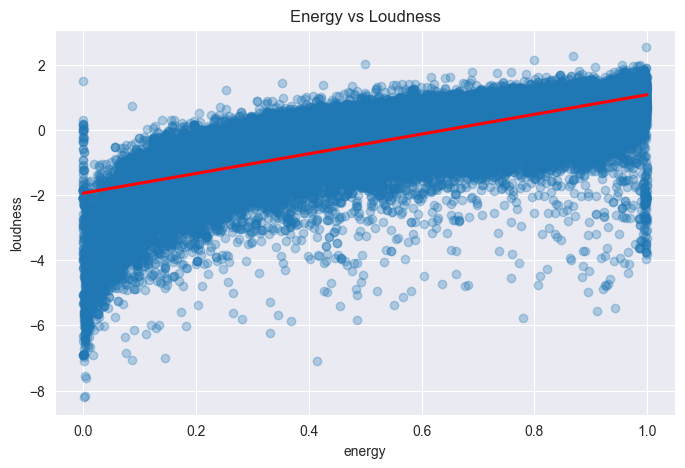

In [78]:
plt.figure(figsize=(8,5))
sns.regplot(x='energy',y='loudness',data=df,
            line_kws={'color':'red'},
            scatter_kws={'alpha':0.3})
plt.title("Energy vs Loudness")
plt.savefig("../visuals/energy_loudness.png")
plt.show()

#### Observation

The scatter plot shows a clear upward trend between energy and loudness. As the energy level of songs increases, their loudness values also tend to increase.

#### Analysis

This indicates a strong positive relationship between energy and loudness. Songs that are more energetic are typically produced with higher volume levels, which aligns with expectations in music production where energetic tracks often sound louder and more intense.

---

---
### Danceability of Popular vs Non-Popular Tracks

To better understand whether danceability influences song popularity, tracks were divided into two groups:

* **Popular Tracks** – songs with popularity values above the defined threshold.
* **Non-Popular Tracks** – songs with popularity values below the threshold.

A boxplot is used to compare the distribution of danceability between these two groups.


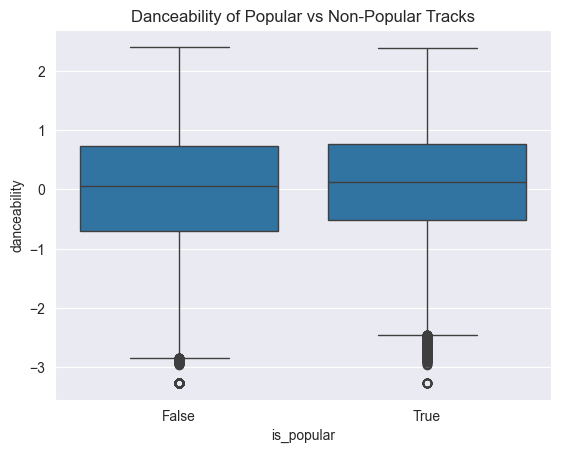

In [79]:
df["is_popular"] = df["popularity"] > 0.5
sns.boxplot(x='is_popular',y='danceability',data=df)
plt.title("Danceability of Popular vs Non-Popular Tracks")
plt.savefig("../visuals/popular_vs_nonpopular.png")
plt.show()

#### Observation

The boxplot shows that popular tracks have a slightly higher median danceability compared to non-popular tracks. However, the overall distributions overlap significantly between the two groups.

#### Analysis

This suggests that danceability may contribute slightly to song popularity, but it is not a decisive factor. Both popular and non-popular songs can have similar danceability levels, indicating that other musical attributes or external factors likely influence popularity as well.

---

---
### Energy vs Song Popularity

Energy represents the intensity and activity level of a song. Higher energy values typically correspond to faster, louder, and more intense tracks.

This analysis examines whether songs with higher energy levels tend to achieve higher popularity.


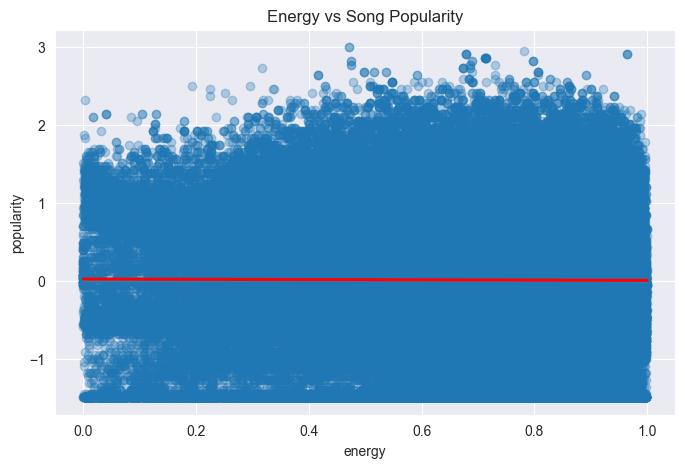

In [80]:
plt.figure(figsize=(8,5))
sns.regplot(x='energy',y='popularity',data=df,
            line_kws={'color':'red'},
            scatter_kws={'alpha':0.3})
plt.title("Energy vs Song Popularity")
plt.savefig("../visuals/energy_vs_popularity.png")
plt.show()

#### Observation

The scatter plot shows a dense distribution of points across the entire range of energy values. The regression line remains nearly flat, indicating that popularity does not change significantly as energy increases.

#### Analysis

This suggests that energy alone does not strongly influence song popularity. Both high-energy and low-energy tracks can achieve similar popularity levels, indicating that popularity is likely influenced by a combination of multiple musical attributes rather than a single feature.

---

---
### Tempo Distribution of Songs

Tempo represents the speed or pace of a song and is typically measured in beats per minute (BPM). Understanding the distribution of tempo values helps reveal whether songs tend to cluster around certain tempo ranges or vary widely across different speeds.


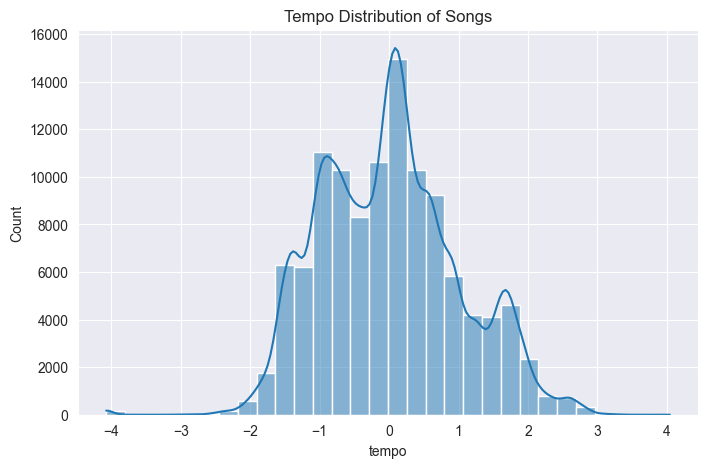

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df['tempo'],bins=30,kde=True)
plt.title("Tempo Distribution of Songs")
plt.savefig("../visuals/tempo_distribution.png")
plt.show()

#### Observation

The histogram shows a bell-shaped distribution centered around the average tempo value. Most songs cluster near the middle of the distribution, while extremely slow or extremely fast songs appear less frequently.

#### Analysis

This suggests that the majority of songs tend to fall within a moderate tempo range. Extremely slow or extremely fast tempos are relatively uncommon, indicating that music producers may prefer tempo ranges that are comfortable for listeners and suitable for mainstream genres.

---

---
### Acousticness vs Popularity

Acousticness represents the likelihood that a track is acoustic rather than electronically produced. Higher values indicate songs that rely more on natural acoustic instruments.

This analysis investigates whether the acoustic nature of a song influences its popularity.


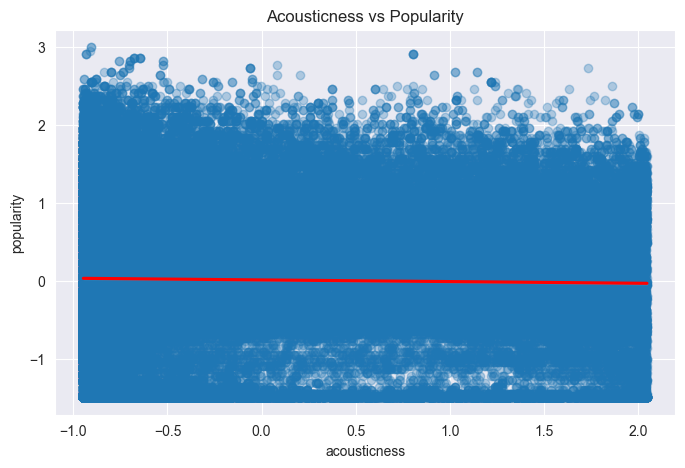

In [82]:
plt.figure(figsize=(8,5))
sns.regplot(x='acousticness',y='popularity',data=df,
            line_kws={'color':'red'},
            scatter_kws={'alpha':0.3})
plt.title("Acousticness vs Popularity")
plt.savefig("../visuals/acousticness_vs_popularity.png")
plt.show()

#### Observation

The scatter plot shows a dense distribution of points across all acousticness values. The regression line remains almost flat, indicating little to no visible trend between acousticness and popularity.

#### Analysis

This suggests that acousticness does not strongly influence song popularity. Both highly acoustic songs and heavily produced electronic tracks can achieve similar popularity levels.

---

---

## Myth Busters

During the exploratory analysis, several common assumptions about music popularity were examined. The results suggest that many of these assumptions do not consistently hold true when observed through the dataset.

### Myth 1: High-energy songs are always more popular

**Reality:**  
The energy vs popularity analysis shows that energy has little to no strong linear relationship with popularity. Songs with both low and high energy levels can achieve similar popularity values.

---

### Myth 2: Acoustic songs are less popular

**Reality:**  
The acousticness vs popularity plot shows that popularity is distributed across the entire acousticness range. This suggests that acoustic songs can perform just as well as electronically produced tracks.

---

### Myth 3: Highly danceable songs guarantee popularity

**Reality:**  
While popular songs tend to have slightly higher danceability on average, the distributions overlap significantly. This indicates that danceability alone does not determine popularity.

---

### Myth 4: Faster songs dominate the charts

**Reality:**  
The tempo distribution shows that most songs cluster around moderate tempo values, and popularity appears across all tempo ranges.

---


---

## Key Takeaways

The analysis of Spotify audio features reveals several important observations:

- Most songs cluster around moderate popularity values rather than extreme highs or lows.

- Danceability shows a mild relationship with popularity, suggesting that danceable songs may have a slightly higher chance of becoming popular.

- Energy and acousticness demonstrate weak relationships with popularity, indicating that no single audio feature strongly determines success.

- A strong positive relationship exists between energy and loudness, reflecting expected patterns in music production.

- Song tempo tends to cluster around moderate ranges, suggesting that extremely slow or extremely fast tracks are less common.

---

--- 

## Final Insights

This exploratory data analysis examined how various Spotify audio features relate to song popularity.

Interestingly, songs with "Average" danceability show slightly higher median popularity than the "Excellent" category. This suggests that extremely high danceability does not necessarily guarantee greater popularity. Moderate levels of danceability may perform just as well, indicating that other factors beyond danceability significantly influence song success.

The results indicate that popularity cannot be explained by a single musical attribute. While certain features such as danceability show mild relationships with popularity, most audio characteristics demonstrate weak correlations.

One of the strongest relationships observed in the dataset is between energy and loudness, which aligns with common music production practices where energetic tracks are typically produced with higher volume levels.

Overall, the findings suggest that song popularity is influenced by a complex combination of musical characteristics and external factors such as artist recognition, marketing, cultural trends, and listener preferences.

---

---

## Conclusion

Through exploratory data analysis and visualization, this project investigated relationships between Spotify audio features and song popularity.

Although some musical attributes show mild influence on popularity, the overall results indicate that no single audio feature dominates song success. Instead, popularity appears to emerge from a combination of musical qualities and external contextual factors.

Future work could extend this analysis by applying machine learning models to predict song popularity or by incorporating additional metadata such as genre, artist popularity, and release year.